In [ ]:
pip install sentence-transformers matplotlib seaborn


In [ ]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket tournament",
    "The wicketkeeper caught the ball behind the stumps",

    # Cooking (3)
    "She cooked a delicious pasta for dinner",
    "The chef prepared a spicy curry",
    "Baking requires precise measurements of ingredients",

    # Cybersecurity (3)
    "Cybersecurity protects systems from cyber attacks",
    "Hackers try to exploit system vulnerabilities",
    "Strong passwords improve online security"
]

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embeddings generated:", len(embeddings))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings generated: 10


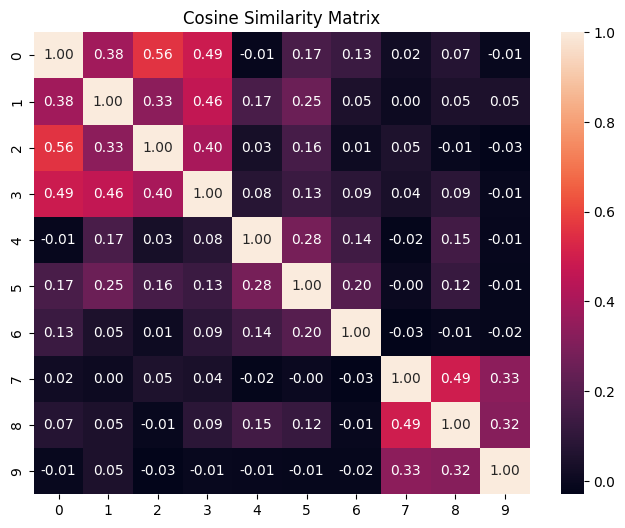

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = np.inner(embeddings, embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f")
plt.title("Cosine Similarity Matrix")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
similarities = np.inner(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:")

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity Score:", round(similarities[i], 4))
    print()

Query: The bowler took three wickets in one over

Top 2 similar sentences:
Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

Sentence: The bowler delivered a fast yorker
Similarity Score: 0.5414

